In [ ]:
# Colab/Notebook setup
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F

torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reproducibility
seed = 123
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)


In [ ]:
# Euclidean projection onto the probability simplex Δ = {x >= 0, sum x = 1}
def proj_simplex(v: torch.Tensor) -> torch.Tensor:
    # Implements sorting-thresholding projection (Condat / Duchi et al.)
    # v: (..., d)
    shape = v.shape
    d = shape[-1]
    u, _ = torch.sort(v.reshape(-1, d), dim=-1, descending=True)
    cssv = torch.cumsum(u, dim=-1) - 1
    ind = torch.arange(1, d + 1, device=v.device, dtype=v.dtype)
    cond = u - cssv / ind > 0
    rho = cond.sum(dim=-1) - 1  # index
    theta = cssv.gather(1, rho.unsqueeze(1)).squeeze(1) / (rho + 1).to(v.dtype)
    w = (v.reshape(-1, d) - theta.unsqueeze(1)).clamp(min=0.0)
    return w.reshape(shape)

# Choose c(x) and c'(x). Since π lives on the simplex (π_i ≥ 0), we can safely use sqrt or log with ε.
# You can toggle between the two by switching which pair is returned in c_pair().
def c_pair():
    eps = 1e-6
    def c(x):      # elementwise
        return torch.sqrt(x + eps)
    def cprime(x): # derivative of sqrt(x+eps) = 1/(2*sqrt(x+eps))
        return 0.5 / torch.sqrt(x + eps)
    return c, cprime

# Matrix powers: returns [P^1, P^2, ..., P^K]
def matrix_powers(P: torch.Tensor, K: int):
    powers = []
    cur = P
    for _ in range(1, K + 1):
        powers.append(cur)
        cur = cur @ P
    return powers  # list of (n,n)

# Helper to compute H_theta(P) = sum_{k=1}^K theta_k * (P^k)
def H_theta(P_powers, theta: torch.Tensor):
    # P_powers: list of length K, each (n,n). theta: (K,)
    K = len(P_powers)
    n = P_powers[0].shape[0]
    H = torch.zeros((n, n), dtype=P_powers[0].dtype, device=P_powers[0].device)
    for k in range(K):
        H = H + theta[k] * P_powers[k]
    return H

# Truncated geometric series S_Ksum(P) = sum_{k=1}^{Ksum} P^k
def truncated_series(P_powers):
    # sum of provided powers
    S = torch.zeros_like(P_powers[0])
    for M in P_powers:
        S = S + M
    return S

# Random w on R^n (fixed across samples or per-sample)
def sample_w(n: int):
    v = torch.rand(n, dtype=torch.get_default_dtype())
    v = v / v.sum()
    return v
# Ensure θ > 0 via a smooth reparametrization

def theta_pos(raw_theta: torch.Tensor) -> torch.Tensor:
    # strictly positive; the tiny epsilon avoids exact zeros
    return F.softplus(raw_theta) + 1e-9


In [ ]:
def proj_simplex_masked(v: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    """
    Project v onto the simplex over the indices where mask==1, set others to 0.
    mask: boolean or {0,1} tensor of shape (n,)
    """
    mask = mask.to(dtype=torch.bool)
    out = torch.zeros_like(v)
    if mask.sum() == 0:
        return out  # no controllable nodes -> all zeros
    x = v[mask]
    # project x onto simplex
    x_proj = proj_simplex(x)
    out[mask] = x_proj
    return out

def masked_like(v: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    return v * mask.to(v.dtype)

def ones_mask(n: int, device=None):
    return torch.ones(n, dtype=torch.bool, device=device)

# For DAGs: choose which nodes are "targets" (non-controllable) and build masks
def dag_sources_mask(P: torch.Tensor):
    indeg = (P > 0).sum(dim=0)     # count incoming positive edges
    return (indeg == 0)

def dag_sinks_mask(P: torch.Tensor):
    outdeg = (P > 0).sum(dim=1)    # count outgoing positive edges
    return (outdeg == 0)

# Toggle: targets are leaves (sinks) or sources. Default here = leaves not controllable.
TARGETS_ARE_LEAVES = True

def dag_targets_mask(P: torch.Tensor):
    return dag_sinks_mask(P) if TARGETS_ARE_LEAVES else dag_sources_mask(P)

def control_mask_from_dag(P: torch.Tensor):
    """Controllable nodes = complement of targets."""
    targets = dag_targets_mask(P)
    return ~targets

def dag_target_w(P: torch.Tensor):
    """
    Build w concentrated on *targets* as per toggle:
      - if TARGETS_ARE_LEAVES=True: mass on leaves (sinks)
      - else: mass on sources
    Fallback: uniform if none exist.
    """
    targets = dag_targets_mask(P)
    n = P.shape[0]
    w = torch.zeros(n, dtype=P.dtype)
    if targets.any():
        w[targets] = 1.0 / targets.sum()
    else:
        w[:] = 1.0 / n
    return w


In [ ]:
# We want P with spectral radius < 1. We'll create row-substochastic matrices with row sums ≤ ρ < 1.
# Optionally we can mix sizes within [n_min, n_max].

# def sample_P(n: int, rho: float = 0.9) -> torch.Tensor:
#     A = torch.rand((n, n), dtype=torch.get_default_dtype())
#     # Normalize rows to sum to 1, then scale each row by a factor in (0, rho)
#     A = A / (A.sum(dim=1, keepdim=True) + 1e-12)
#     scales = (0.5 + 0.5 * torch.rand(n, dtype=A.dtype)).unsqueeze(1)  # in (0.5, 1.0)
#     A = A * (rho * scales)  # row sums in (0, rho]
#     return A

# def make_dataset(num_mats: int, n_min: int = 10, n_max: int = 30, rho: float = 0.9):
#     Ps = []
#     sizes = []
#     for _ in range(num_mats):
#         n = random.randint(n_min, n_max)
#         P = sample_P(n, rho=rho)
#         Ps.append(P.to(device))
#         sizes.append(n)
#     return Ps, sizes

# # Quick smoke test
# Ps_train, sizes_train = make_dataset(num_mats=5, n_min=8, n_max=12)
# [p.shape for p in Ps_train], sizes_train[:3]


In [ ]:
# DAG (acyclic) generator for P with edges going from earlier to later layers.
# Row-substochastic with row sums ≤ rho, so spectral radius < 1 and sums of powers converge.

#First need create a number of nodes per layer. We first add floor n/nb layer per layers. Then for the remaining We add from the first to last layer depening of the size of the remainder. Then we add an edge to only from lower layer to higher layer
 #Ensure every non-sink node has at least one outgoing edge;
# if a row is all zeros, connect to a random node in a higher layer if possible.

def sample_DAG_P(n: int,
                 n_layers: int = None,
                 edge_prob: float = 0.25,
                 rho: float = 0.9) -> torch.Tensor:
    """
    Create a random DAG adjacency (u->v only if layer(u) < layer(v)),
    then normalize outgoing rows and scale to be row-substochastic (≤ rho).
    """
    if n_layers is None:
        n_layers = max(2, int(round(math.sqrt(n))))  # a reasonable default
    # Assign nodes to layers in order
    # e.g., layers like [0,0,1,1,1,2,...] covering all nodes
    layer_sizes = [n // n_layers] * n_layers
    remainder = n % n_layers
    for i in range(remainder):
        layer_sizes[i] += 1
    layers = []
    idx = 0
    for L, sz in enumerate(layer_sizes):
        layers.extend([L] * sz)
        idx += sz
    layers = torch.tensor(layers)

    A = torch.zeros((n, n), dtype=torch.get_default_dtype())
    # Add edges only from lower layer to higher layer
    for u in range(n):
        for v in range(n):
            if layers[u] < layers[v]:
                if random.random() < edge_prob:
                    A[u, v] = random.random()

    # Ensure every non-sink node has at least one outgoing edge;
    # if a row is all zeros, connect to a random node in a higher layer if possible.
    for u in range(n):
        if A[u].sum() == 0:
            # find candidate higher-layer nodes
            candidates = [v for v in range(n) if layers[u] < layers[v]]
            if candidates:
                v = random.choice(candidates)
                A[u, v] = 1.0

    # Normalize rows and scale by per-row factor in (0, rho]
    row_sums = A.sum(dim=1, keepdim=True)
    # For sink rows (all zeros), keep them zeros (pure absorbing/no-outflow)
    nonzero = row_sums.squeeze(1) > 0
    A_norm = torch.zeros_like(A)
    A_norm[nonzero] = A[nonzero] / (row_sums[nonzero] + 1e-12)
    scales = torch.ones(n, 1, dtype=A.dtype)
    scales[nonzero] = (0.5 + 0.5 * torch.rand((nonzero.sum(), 1), dtype=A.dtype)) * rho
    P = A_norm * scales
    return P

def make_dag_dataset(num_mats: int,
                     n_min: int = 10,
                     n_max: int = 30,
                     rho: float = 0.9,
                     edge_prob: float = 0.25):
    Ps = []
    sizes = []
    for _ in range(num_mats):
        n = random.randint(n_min, n_max)
        P = sample_DAG_P(n, n_layers=None, edge_prob=edge_prob, rho=rho)
        Ps.append(P.to(device))
        sizes.append(n)
    return Ps, sizes

def dag_sources_mask(P: torch.Tensor):
    """Boolean mask of 'initial nodes' (in-degree 0) for the directed graph of P."""
    # in-degree > 0 if any u->v edge exists with positive weight to node v
    indeg = (P > 0).sum(dim=0)  # count of positive incoming edges per node
    return (indeg == 0)

def dag_target_w(P: torch.Tensor):
    """
    Target vector w concentrated on initial nodes (sources).
    If there are no pure sources (rare with forced edges), fallback to uniform.
    """
    mask = dag_sources_mask(P)
    n = P.shape[0]
    if mask.any():
        w = torch.zeros(n, dtype=P.dtype)
        w[mask] = 1.0 / mask.sum()
    else:
        # Fallback (should be rare)
        w = torch.full((n,), 1.0 / n, dtype=P.dtype)
    return w

# Quick smoke test for DAG creation
P_dag = sample_DAG_P(14, edge_prob=0.3, rho=0.9).to(device)
print("DAG P shape:", P_dag.shape, "Row sums max:", P_dag.sum(1).max().item())
print("Number of sources:", dag_sources_mask(P_dag).sum().item())


DAG P shape: torch.Size([14, 14]) Row sums max: 0.8768459143515275
Number of sources: 4


In [ ]:
# The constraint defines π = Γ_Π[ π + α * diag(c'(π)) * ( H(P,θ)^T w ) ].
# We'll find a fixed point by iterating this operator; with small α this mapping is typically a contraction.

def fixed_point_pi(P: torch.Tensor,
                   theta: torch.Tensor,
                   w: torch.Tensor,
                   alpha: float = 0.5,
                   K: int = 5,
                   max_iter: int = 200,
                   tol: float = 1e-7,
                   control_mask: torch.Tensor = None):
    """
    Solve π = Γ_Π[ π + α * diag(c'(π)) * (H(P,θ)^T w) ]
    but ONLY over controllable indices (mask==1). Non-controllable entries are fixed at 0.
    """
    n = P.shape[0]
    c, cprime = c_pair()
    if control_mask is None:
        control_mask = ones_mask(n, P.device)

    P_powers = matrix_powers(P, K)
    H = H_theta(P_powers, theta)
    g = (H.T @ w)  # (n,)

    # initialize π on controllable simplex; zeros on non-controllable
    pi = torch.zeros(n, dtype=P.dtype, device=P.device)
    if control_mask.sum() > 0:
        pi[control_mask] = 1.0 / control_mask.sum()

    for _ in range(max_iter):
        old = pi
        # Only controllable coordinates receive gradient-like step
        step = alpha * masked_like(cprime(pi), control_mask) * g
        pi = proj_simplex_masked(pi + step, control_mask)
        if torch.norm(pi - old, p=2).item() < tol:
            break
    return pi




In [ ]:
# The empirical objective per sample:
# J(P, θ) = 1^T [ diag(c'(π_θ(P))) * ( sum_{k=1}^{Ksum} P^k )^T w ]
# We'll sum entries to get a scalar (maximize).

def sample_objective(P: torch.Tensor,
                     theta: torch.Tensor,
                     w: torch.Tensor,
                     alpha: float,
                     K: int,
                     Ksum: int,
                     control_mask: torch.Tensor = None):
    """
    J(P, θ) = sum_i [ c'(π_i) * ((sum_{k=1}^{Ksum} P^k)^T w)_i ] but only over controllable i.
    """
    n = P.shape[0]
    if control_mask is None:
        control_mask = ones_mask(n, P.device)

    c, cprime = c_pair()
    pi = fixed_point_pi(P, theta, w, alpha=alpha, K=K, control_mask=control_mask)
    P_series = truncated_series(matrix_powers(P, Ksum))  # (n,n)
    vec = (P_series.T @ w)  # (n,)

    weight = masked_like(cprime(pi), control_mask)
    val = (weight * vec).sum()
    return val

@torch.no_grad()
def evaluate_objective(Ps, theta, alpha, K, Ksum, dag_mode=False):
    vals = []
    for P in Ps:
        n = P.shape[0]
        if dag_mode:
            w = dag_target_w(P).to(device)
            control_mask = control_mask_from_dag(P).to(device)
        else:
            w = sample_w(n).to(device)
            control_mask = ones_mask(n, device=device)
        v = sample_objective(P, theta, w, alpha=alpha, K=K, Ksum=Ksum, control_mask=control_mask)
        vals.append(v.item())
    return float(np.mean(vals)), float(np.std(vals))


In [ ]:
# Hyperparameters
K = 3
Ksum = 20
alpha = 0.5
epochs = 60
train_mats = 30
test_mats = 30
nmin, nmax = 12, 28
lr = 5e-2
grad_clip = 1.0

# Choose dataset type:
TRAIN_ON_DAG = True  # set False to use general random graphs

if TRAIN_ON_DAG:
    Ps_train, _ = make_dag_dataset(train_mats, n_min=nmin, n_max=nmax, edge_prob=0.3)
    Ps_test,  _ = make_dag_dataset(test_mats,  n_min=nmin, n_max=nmax, edge_prob=0.3)
else:
    Ps_train, _ = make_dataset(train_mats, n_min=nmin, n_max=nmax)
    Ps_test,  _ = make_dataset(test_mats,  n_min=nmin, n_max=nmax)

# Positive θ via softplus parametrization
raw_theta = nn.Parameter(torch.zeros(K, dtype=torch.get_default_dtype(), device=device))
optimizer = optim.Adam([raw_theta], lr=lr)

train_hist, test_hist = [], []

for ep in range(1, epochs + 1):
    optimizer.zero_grad()
    for P in Ps_train:
        n = P.shape[0]
        if TRAIN_ON_DAG:
            w = dag_target_w(P).to(device)
            control_mask = control_mask_from_dag(P).to(device)
        else:
            w = sample_w(n).to(device)
            control_mask = ones_mask(n, device=device)

        theta = theta_pos(raw_theta)
        val = sample_objective(P, theta, w, alpha=alpha, K=K, Ksum=Ksum, control_mask=control_mask)

        loss = -val
        loss.backward()
        #nn.utils.clip_grad_norm_([raw_theta], grad_clip)
        optimizer.step()
        optimizer.zero_grad()

    with torch.no_grad():
        theta_eval = theta_pos(raw_theta)
        train_mean, _ = evaluate_objective(Ps_train, theta_eval, alpha, K, Ksum, dag_mode=TRAIN_ON_DAG)
        test_mean, _  = evaluate_objective(Ps_test,  theta_eval, alpha, K, Ksum, dag_mode=TRAIN_ON_DAG)
    train_hist.append(train_mean)
    test_hist.append(test_mean)

    if ep % 10 == 0 or ep == 1:
        print(f"[Epoch {ep:03d}] train={train_mean:.4f} test={test_mean:.4f} | θ={theta_eval.detach().cpu().numpy()}")

theta_star = theta_pos(raw_theta).detach().cpu().numpy()
theta_star



[Epoch 001] train=129.6624 test=116.5148 | θ=[0.52605542 0.5260558  0.88376882]
[Epoch 010] train=129.7796 test=116.3404 | θ=[0.51757052 0.5175709  0.82358739]
[Epoch 020] train=131.1439 test=98.8824 | θ=[0.51757052 0.5175709  0.44172085]
[Epoch 030] train=131.1439 test=98.8813 | θ=[0.51757052 0.5175709  0.44084733]
[Epoch 040] train=131.1439 test=98.2958 | θ=[0.51757052 0.5175709  0.4397142 ]
[Epoch 050] train=131.1439 test=108.3377 | θ=[0.51757052 0.5175709  0.43829885]
[Epoch 060] train=131.1439 test=108.4770 | θ=[0.51757052 0.5175709  0.43656665]


array([0.51757052, 0.5175709 , 0.43656665])

In [ ]:
5e-2

0.05

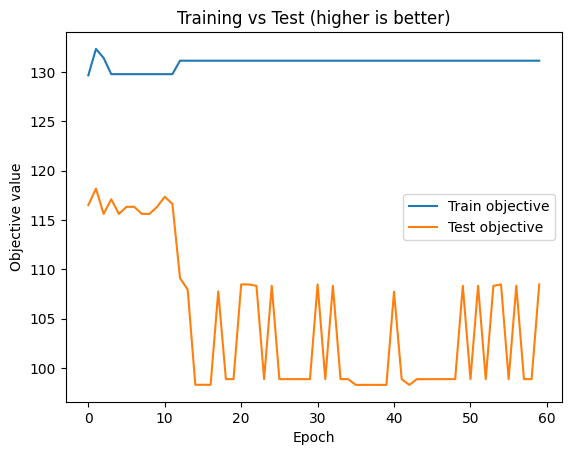

In [ ]:
plt.figure()
plt.plot(train_hist, label="Train objective")
plt.plot(test_hist, label="Test objective")
plt.xlabel("Epoch")
plt.ylabel("Objective value")
plt.title("Training vs Test (higher is better)")
plt.legend()
plt.show()


In [ ]:
import networkx as nx

def proxy_optimal_policy(P: torch.Tensor, w: torch.Tensor, Ksum: int, softmax_temp: float = None,
                         control_mask: torch.Tensor = None):
    """
    Proxy-optimal over controllable nodes only:
      v = (sum_{k=1}^{Ksum} P^k)^T w; maximize <π, v> s.t. π in simplex over {i: control_mask_i=1}
    """
    n = P.shape[0]
    if control_mask is None:
        control_mask = ones_mask(n, P.device)

    S = truncated_series(matrix_powers(P, Ksum))
    v = (S.T @ w)  # (n,)
    v_masked = v.clone()

    if softmax_temp is None:
        # Hard argmax over allowed set
        v_masked[~control_mask] = -1e30
        pi = torch.zeros_like(v)
        idx = int(torch.argmax(v_masked).item()) if control_mask.any() else None
        if idx is not None:
            pi[idx] = 1.0
        return pi
    else:
        vv = v / softmax_temp
        vv[~control_mask] = -1e30
        vv = vv - vv.max()
        ex = torch.exp(vv)
        ex[~control_mask] = 0.0
        s = ex.sum()
        return ex / (s + 1e-12)

def build_graph_from_P(P: torch.Tensor, edge_threshold: float = 1e-3, max_edges: int = 400):
    n = P.shape[0]
    G = nx.DiGraph()
    G.add_nodes_from(range(n))
    edges = []
    rows, cols = torch.nonzero(P > edge_threshold, as_tuple=True)
    for i, j in zip(rows.tolist(), cols.tolist()):
        edges.append((i, j, float(P[i, j].item())))
    edges = sorted(edges, key=lambda e: e[2], reverse=True)[:max_edges]
    for i, j, w in edges:
        G.add_edge(i, j, weight=w)
    return G

def is_dag_graph(G: nx.DiGraph) -> bool:
    try:
        return nx.is_directed_acyclic_graph(G)
    except Exception:
        return False

def _dag_layered_layout(G: nx.DiGraph):
    sources = [n for n in G.nodes() if G.in_degree(n) == 0]
    if not sources:
        return nx.spring_layout(G, seed=42)
    dist = {u: 0 for u in G.nodes()}
    topo = list(nx.topological_sort(G))
    for u in topo:
        for v in G.successors(u):
            dist[v] = max(dist.get(v, 0), dist[u] + 1)
    levels = {}
    for u, d in dist.items():
        levels.setdefault(d, []).append(u)
    pos = {}
    xgap = 2.0
    ygap = 1.0
    for lvl, nodes in sorted(levels.items()):
        m = len(nodes)
        ys = np.linspace(- (m-1) * ygap / 2.0, (m-1) * ygap / 2.0, m) if m > 1 else [0.0]
        for y, u in zip(ys, nodes):
            pos[u] = (lvl * xgap, y)
    return pos

def draw_graph_policy(P: torch.Tensor,
                      pi: torch.Tensor,
                      title: str = "",
                      edge_threshold: float = 1e-3,
                      max_edges: int = 400,
                      node_size_base: float = 500.0,
                      prefer_dag_layout: bool = True,
                      control_mask: torch.Tensor = None):
    P_cpu = P.detach().cpu()
    pi_cpu = pi.detach().cpu()
    n = P_cpu.shape[0]
    if control_mask is None:
        control_mask = ones_mask(n, device=P_cpu.device)
    control_mask = control_mask.detach().cpu()

    G = build_graph_from_P(P_cpu, edge_threshold=edge_threshold, max_edges=max_edges)
    pos = _dag_layered_layout(G) if (prefer_dag_layout and is_dag_graph(G)) else nx.spring_layout(G, seed=42, k=None)

    pi_np = pi_cpu.numpy()
    sizes = node_size_base * (0.2 + 0.8 * (pi_np / (pi_np.max() + 1e-12)))
    colors = (pi_np - pi_np.min()) / (pi_np.max() - pi_np.min() + 1e-12)

    plt.figure(figsize=(8, 6))
    nodes = nx.draw_networkx_nodes(G, pos,
                                   node_color=colors,
                                   node_size=sizes,
                                   cmap=plt.cm.viridis)
    plt.colorbar(nodes, fraction=0.045, pad=0.04, label="Policy mass π_i")

    # Highlight non-controllable nodes with a thick outline
    nc_nodes = [i for i in G.nodes() if not bool(control_mask[i])]
    if nc_nodes:
        nx.draw_networkx_nodes(G, pos, nodelist=nc_nodes,
                               node_color='none', edgecolors='red',
                               linewidths=2.2, node_size=[sizes[i] for i in nc_nodes])

    weights = [G[u][v]['weight'] for u, v in G.edges()]
    if len(weights) > 0:
        w_min, w_max = min(weights), max(weights)
        widths = [1.0 + 3.0 * ((w - w_min) / (w_max - w_min + 1e-12)) for w in weights]
    else:
        widths = None
    nx.draw_networkx_edges(G, pos, arrows=True, width=widths, alpha=0.35)
    nx.draw_networkx_labels(G, pos, font_size=9)

    plt.title(title)
    plt.axis("off")
    plt.show()

def bar_compare_policies(pi_a: torch.Tensor, pi_b: torch.Tensor, labels=("Learned π", "Proxy-opt π*")):
    pi_a = pi_a.detach().cpu().numpy()
    pi_b = pi_b.detach().cpu().numpy()
    n = len(pi_a)
    x = np.arange(n)
    w = 0.42
    plt.figure(figsize=(9, 4))
    plt.bar(x - w/2, pi_a, width=w, label=labels[0])
    plt.bar(x + w/2, pi_b, width=w, label=labels[1])
    plt.xlabel("Node index")
    plt.ylabel("Probability")
    plt.title("Policy comparison per node")
    plt.legend()
    plt.tight_layout()
    plt.show()


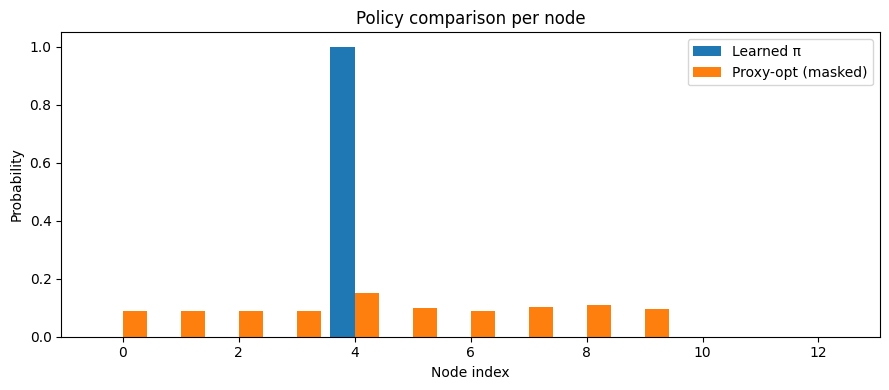

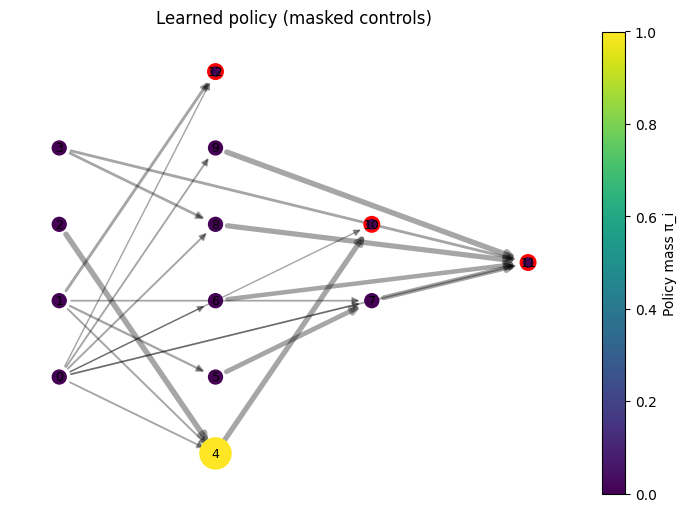

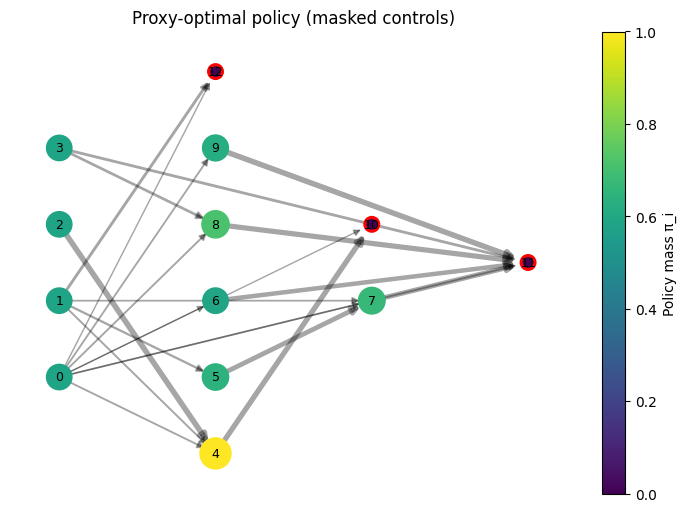

In [ ]:
use_dag_dataset = True
index_in_set = 0
softmax_temp = 0.5
edge_threshold = 1e-2
max_edges = 500

# Pool for visualization
if use_dag_dataset:
    Ps_pool, _ = make_dag_dataset(num_mats=6, n_min=12, n_max=24, edge_prob=0.3)
else:
    Ps_pool = Ps_train

P = Ps_pool[index_in_set].to(device)
n = P.shape[0]

# Targets & masks
G_tmp = build_graph_from_P(P.detach().cpu(), edge_threshold=1e-12, max_edges=10**9)
if use_dag_dataset and is_dag_graph(G_tmp):
    w = dag_target_w(P).to(device)
    control_mask = control_mask_from_dag(P).to(device)
else:
    w = sample_w(n).to(device)
    control_mask = ones_mask(n, device=device)

with torch.no_grad():
    theta_viz = theta_pos(raw_theta)
    pi_learned = fixed_point_pi(P, theta_viz, w, alpha=alpha, K=K, control_mask=control_mask)
    pi_opt     = proxy_optimal_policy(P, w, Ksum=Ksum, softmax_temp=softmax_temp, control_mask=control_mask)

# Bars
bar_compare_policies(pi_learned, pi_opt, labels=("Learned π", "Proxy-opt (masked)"))

# Graphs (non-controllable nodes outlined in red)
draw_graph_policy(P, pi_learned, title="Learned policy (masked controls)",
                  edge_threshold=edge_threshold, max_edges=max_edges, prefer_dag_layout=True,
                  control_mask=control_mask)

draw_graph_policy(P, pi_opt, title="Proxy-optimal policy (masked controls)",
                  edge_threshold=edge_threshold, max_edges=max_edges, prefer_dag_layout=True,
                  control_mask=control_mask)


# Train on a single instance

In [ ]:
# --- Single-instance configuration ---



SINGLE_N = 20
SINGLE_EDGE_PROB = 0.30
SINGLE_RHO = 0.9
TARGETS_ARE_LEAVES = True  # <- targets are initial nodes (sources), as discussed

# Build one DAG P
P_single = sample_DAG_P(SINGLE_N, edge_prob=SINGLE_EDGE_PROB, rho=SINGLE_RHO).to(device)

# Target vector w on sources (since TARGETS_ARE_LEAVES=False)
w_single = dag_target_w(P_single).to(device)

# Control mask excludes leaves (non-controllable): π_i=0 on sinks
control_mask_single = control_mask_from_dag(P_single).to(device)

# Quick sanity
print("DAG?  ", nx.is_directed_acyclic_graph(build_graph_from_P(P_single.detach().cpu(), 1e-12, 10**9)))
print("sources (|w>0|):", int((w_single > 0).sum().item()),
      "sinks (excluded):", int((~control_mask_single).sum().item()))


DAG?   True
sources (|w>0|): 5 sinks (excluded): 5


In [ ]:


# Hyperparameters (you can tweak)
K = 3
Ksum = 20
alpha = 0.5
epochs_single = 100
lr_single = 5e-2
grad_clip = 1.0

# Fresh θ for the single problem (positive via softplus)
raw_theta_single = nn.Parameter(torch.zeros(K, dtype=torch.get_default_dtype(), device=device))
opt_single = optim.Adam([raw_theta_single], lr=lr_single)

train_hist_single = []

for ep in range(1, epochs_single + 1):
    opt_single.zero_grad()

    theta_now = theta_pos(raw_theta_single)
    # Single-instance empirical objective
    val = sample_objective(P_single, theta_now, w_single,
                           alpha=alpha, K=K, Ksum=Ksum,
                           control_mask=control_mask_single)

    loss = -val  # maximize val
    loss.backward()
    nn.utils.clip_grad_norm_([raw_theta_single], grad_clip)
    opt_single.step()

    train_hist_single.append(val.item())
    if ep % 10 == 0 or ep == 1:
        print(f"[Single EP {ep:03d}] objective={val.item():.6f} | θ={theta_now.detach().cpu().numpy()}")


[Single EP 001] objective=225.330596 | θ=[0.69314718 0.69314718 0.69314718]
[Single EP 010] objective=225.330596 | θ=[0.69314718 0.69314718 0.69314718]
[Single EP 020] objective=225.330596 | θ=[0.69314718 0.69314718 0.69314718]
[Single EP 030] objective=225.330596 | θ=[0.69314718 0.69314718 0.69314718]
[Single EP 040] objective=225.330596 | θ=[0.69314718 0.69314718 0.69314718]
[Single EP 050] objective=225.330596 | θ=[0.69314718 0.69314718 0.69314718]
[Single EP 060] objective=225.330596 | θ=[0.69314718 0.69314718 0.69314718]
[Single EP 070] objective=225.330596 | θ=[0.69314718 0.69314718 0.69314718]
[Single EP 080] objective=225.330596 | θ=[0.69314718 0.69314718 0.69314718]
[Single EP 090] objective=225.330596 | θ=[0.69314718 0.69314718 0.69314718]
[Single EP 100] objective=225.330596 | θ=[0.69314718 0.69314718 0.69314718]


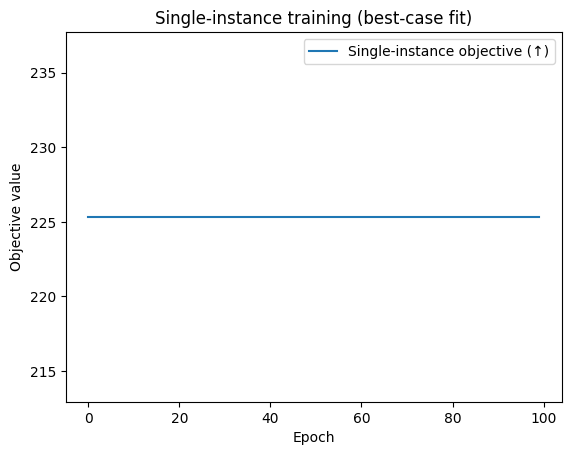

In [ ]:
plt.figure()
plt.plot(train_hist_single, label="Single-instance objective (↑)")
plt.xlabel("Epoch")
plt.ylabel("Objective value")
plt.title("Single-instance training (best-case fit)")
plt.legend()
plt.show()


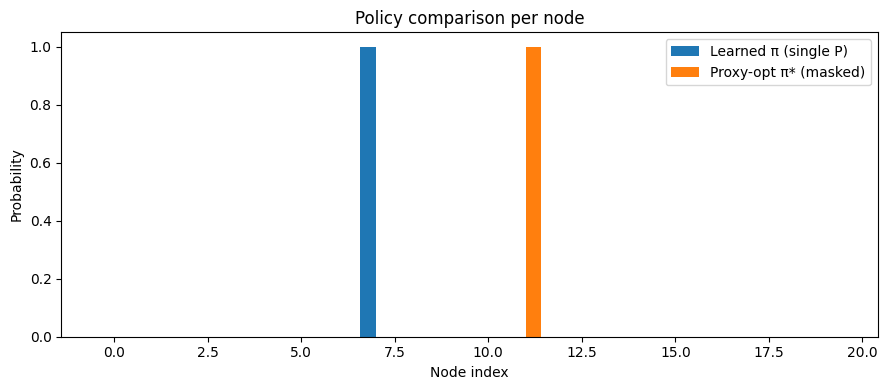

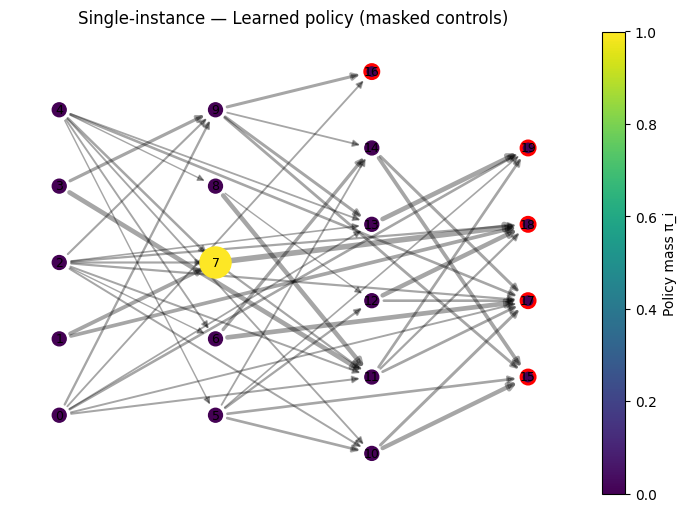

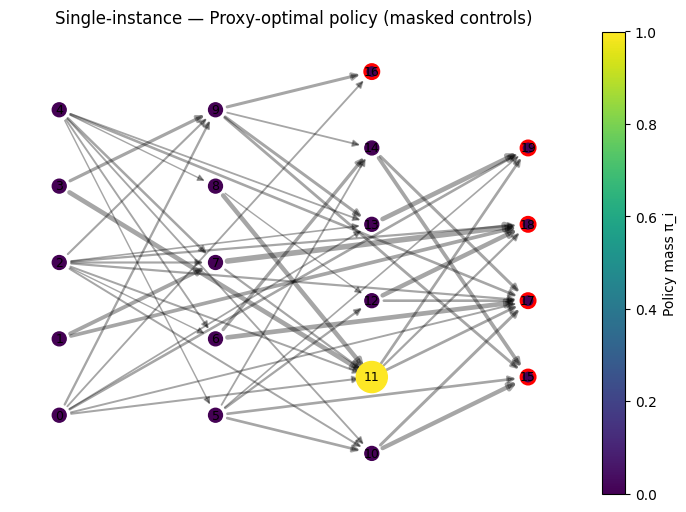

In [ ]:
# Learned π from θ* on this instance
with torch.no_grad():
    theta_star_single = theta_pos(raw_theta_single)
    pi_learned_single = fixed_point_pi(P_single, theta_star_single, w_single,
                                       alpha=alpha, K=K, control_mask=control_mask_single)

# "Optimal" proxy policy under the linear surrogate v = (sum P^k)^T w (masked onto controllable set)
pi_proxy_opt_single = proxy_optimal_policy(P_single, w_single, Ksum=Ksum,
                                           softmax_temp=None,  # one-hot; set to >0 for smooth
                                           control_mask=control_mask_single)

# Bar comparison
bar_compare_policies(pi_learned_single, pi_proxy_opt_single,
                     labels=("Learned π (single P)", "Proxy-opt π* (masked)"))

# Graph drawings (non-controllable nodes outlined in red)
draw_graph_policy(P_single, pi_learned_single, title="Single-instance — Learned policy (masked controls)",
                  edge_threshold=1e-2, max_edges=600, prefer_dag_layout=True,
                  control_mask=control_mask_single)

draw_graph_policy(P_single, pi_proxy_opt_single, title="Single-instance — Proxy-optimal policy (masked controls)",
                  edge_threshold=1e-2, max_edges=600, prefer_dag_layout=True,
                  control_mask=control_mask_single)


# New notebook

In [ ]:
import math, random, numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F

torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import matplotlib.pyplot as plt

# Optional for graph visualization:
# !pip install networkx
import networkx as nx

torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed = 42
random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)


In [ ]:
def proj_simplex(v: torch.Tensor) -> torch.Tensor:
    # Euclidean projection onto simplex {x >= 0, sum x = 1} (Duchi/Condat)
    shape = v.shape
    d = shape[-1]
    u, _ = torch.sort(v.reshape(-1, d), dim=-1, descending=True)
    cssv = torch.cumsum(u, dim=-1) - 1
    ind = torch.arange(1, d + 1, device=v.device, dtype=v.dtype)
    cond = u - cssv / ind > 0
    rho = cond.sum(dim=-1) - 1
    theta = cssv.gather(1, rho.unsqueeze(1)).squeeze(1) / (rho + 1).to(v.dtype)
    w = (v.reshape(-1, d) - theta.unsqueeze(1)).clamp(min=0.0)
    return w.reshape(shape)

def c_pair():
    eps = 1e-6
    def c(x):      return torch.sqrt(x + eps)
    def cprime(x): return 0.5 / torch.sqrt(x + eps)
    return c, cprime

def matrix_powers(P: torch.Tensor, K: int):
    powers, cur = [], P
    for _ in range(1, K+1):
        powers.append(cur)
        cur = cur @ P
    return powers

def truncated_series(P_powers):
    S = torch.zeros_like(P_powers[0])
    for M in P_powers: S = S + M
    return S
import torch.nn.functional as F

def theta_pos(raw_theta: torch.Tensor) -> torch.Tensor:
    return F.softplus(raw_theta) + 1e-9  # strictly positive


In [ ]:
def _balanced_layer_sizes_single_sink(n: int, n_layers: int):
    # Ensure the last layer has exactly 1 node (unique sink)
    assert n_layers >= 2 and n >= n_layers, "Need at least 2 layers and n >= n_layers"
    last = 1
    rem = n - last
    base = rem // (n_layers - 1)
    sizes = [base] * (n_layers - 1)
    for i in range(rem % (n_layers - 1)):
        sizes[i] += 1
    sizes.append(last)  # final layer = unique sink
    return sizes

def sample_DAG_single_sink(n: int, n_layers: int = None, edge_prob: float = 0.25):
    """
    Build a DAG with a unique sink (last layer has 1 node).
    Non-sink rows are normalized to sum exactly to 1 (row-stochastic).
    The sink row remains all zeros -> absorbing.
    """
    if n_layers is None:
        n_layers = max(2, int(round(math.sqrt(n))))

    sizes = _balanced_layer_sizes_single_sink(n, n_layers)

    # Assign layer index per node
    layers = []
    for L, sz in enumerate(sizes):
        layers.extend([L] * sz)
    layers = torch.tensor(layers)

    # Adjacency (weights) only from lower to higher layers
    A = torch.zeros((n, n), dtype=torch.get_default_dtype())
    for u in range(n):
        for v in range(n):
            if layers[u] < layers[v] and random.random() < edge_prob:
                A[u, v] = random.random()

    # Ensure each non-sink has ≥1 outgoing edge to a higher layer
    for u in range(n):
        if layers[u] == (n_layers - 1):  # last layer: the unique sink
            continue
        if A[u].sum() == 0:
            candidates = [v for v in range(n) if layers[v] > layers[u]]
            v = random.choice(candidates)
            A[u, v] = 1.0

    # Normalize rows: non-sinks become row-stochastic; sink stays zero (absorbing)
    row_sums = A.sum(dim=1, keepdim=True)
    P = torch.zeros_like(A)
    nonzero = row_sums.squeeze(1) > 0
    P[nonzero] = A[nonzero] / (row_sums[nonzero] + 1e-12)
    # rows with no outgoing edges (the unique sink) remain zero

    return P

def make_dag_dataset_single_sink(num_mats: int, n_min: int = 12, n_max: int = 28, edge_prob: float = 0.3):
    Ps = []
    for _ in range(num_mats):
        n = random.randint(n_min, n_max)
        P = sample_DAG_single_sink(n, n_layers=None, edge_prob=edge_prob)
        Ps.append(P.to(device))
    return Ps


def make_dag_dataset_single_sink(num_mats: int, n_min: int = 12, n_max: int = 28, edge_prob: float = 0.3):
    Ps = []
    for _ in range(num_mats):
        n = random.randint(n_min, n_max)
        P = sample_DAG_single_sink(n, n_layers=None, edge_prob=edge_prob)
        Ps.append(P.to(device))
    return Ps



In [ ]:
def dag_sources_mask(P: torch.Tensor):
    indeg = (P > 0).sum(dim=0)
    return (indeg == 0)

def dag_sinks_mask(P: torch.Tensor):
    outdeg = (P > 0).sum(dim=1)
    return (outdeg == 0)

# Our target set 𝒯 is the (unique) leaf; control = complement
def targets_mask(P: torch.Tensor):
    return dag_sinks_mask(P)

def control_mask_from_dag(P: torch.Tensor):
    return ~targets_mask(P)  # target not controllable


In [ ]:
def w_from_sources(P: torch.Tensor):
    sources = dag_sources_mask(P)
    n = P.shape[0]
    w = torch.zeros(n, dtype=P.dtype, device=P.device)
    if sources.any():
        w[sources] = 1.0 / sources.sum()
    else:
        w[:] = 1.0 / n
    return w


In [ ]:
def proj_simplex_masked(v: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    mask = mask.to(torch.bool)
    out = torch.zeros_like(v)
    if mask.sum() == 0: return out
    x = v[mask]
    out[mask] = proj_simplex(x)
    return out

def H_theta(P_powers, theta: torch.Tensor):
    H = torch.zeros_like(P_powers[0])
    for k in range(len(P_powers)):
        H = H + theta[k] * P_powers[k]
    return H

def fixed_point_pi(P: torch.Tensor,
                   theta: torch.Tensor,
                   w: torch.Tensor,
                   alpha: float = 0.5,
                   K: int = 6,
                   max_iter: int = 200,
                   tol: float = 1e-7,
                   control_mask: torch.Tensor = None):
    n = P.shape[0]
    c, cprime = c_pair()
    if control_mask is None:
        control_mask = torch.ones(n, dtype=torch.bool, device=P.device)

    P_powers = matrix_powers(P, K)
    H = H_theta(P_powers, theta)
    g = (H.T @ w)  # (n,)

    pi = torch.zeros(n, dtype=P.dtype, device=P.device)
    if control_mask.sum() > 0:
        pi[control_mask] = 1.0 / control_mask.sum()

    for _ in range(max_iter):
        old = pi
        step = alpha * (cprime(pi) * g)
        # freeze target by projecting only on controllable coordinates
        pi = proj_simplex_masked(pi + step, control_mask)
        if torch.norm(pi - old, p=2).item() < tol:
            break
    return pi


In [ ]:
def sample_objective(P: torch.Tensor,
                     theta: torch.Tensor,
                     w: torch.Tensor,
                     alpha: float,
                     K: int,
                     Ksum: int,
                     control_mask: torch.Tensor):
    c, cprime = c_pair()
    pi = fixed_point_pi(P, theta, w, alpha=alpha, K=K, control_mask=control_mask)
    vec = (truncated_series(matrix_powers(P, Ksum)).T @ w)
    weight = cprime(pi) * control_mask.to(P.dtype)
    return (weight * vec).sum()

@torch.no_grad()
def evaluate_objective(Ps, theta, alpha, K, Ksum):
    vals = []
    for P in Ps:
        w = w_from_sources(P).to(device)
        control_mask = control_mask_from_dag(P).to(device)
        v = sample_objective(P, theta, w, alpha=alpha, K=K, Ksum=Ksum, control_mask=control_mask)
        vals.append(v.item())
    return float(np.mean(vals)), float(np.std(vals))


In [ ]:
# Hyperparameters
K = 7          # number of θ_k terms
Ksum = 20      # truncation for sum P^k
alpha = 0.5
epochs = 60
train_mats = 30
test_mats = 30
nmin, nmax = 12, 28
lr = 5e-2
#grad_clip = 1.0

# Build datasets: single-sink DAGs
Ps_train = make_dag_dataset_single_sink(train_mats, n_min=nmin, n_max=nmax, edge_prob=0.3)
Ps_test  = make_dag_dataset_single_sink(test_mats,  n_min=nmin, n_max=nmax, edge_prob=0.3)

# Enforce θ>0 via softplus
raw_theta = nn.Parameter(torch.zeros(K, dtype=torch.get_default_dtype(), device=device))
opt = optim.Adam([raw_theta], lr=lr)

train_hist, test_hist = [], []

for ep in range(1, epochs+1):
    opt.zero_grad()
    for P in Ps_train:
        w = w_from_sources(P).to(device)
        control_mask = control_mask_from_dag(P).to(device)
        theta = theta_pos(raw_theta)
        val = sample_objective(P, theta, w, alpha=alpha, K=K, Ksum=Ksum, control_mask=control_mask)
        loss = -val
        loss.backward()
        #nn.utils.clip_grad_norm_([raw_theta], grad_clip)
        opt.step()
        opt.zero_grad()

    with torch.no_grad():
        theta_eval = theta_pos(raw_theta)
        tr_mean, _ = evaluate_objective(Ps_train, theta_eval, alpha, K, Ksum)
        te_mean, _ = evaluate_objective(Ps_test,  theta_eval, alpha, K, Ksum)
    train_hist.append(tr_mean); test_hist.append(te_mean)

    if ep % 10 == 0 or ep == 1:
        print(f"[Epoch {ep:03d}] train={tr_mean:.4f}  test={te_mean:.4f}  | θ={theta_eval.detach().cpu().numpy()}")


In [ ]:
plt.figure(figsize=(6,4))
plt.plot(train_hist, label="Train objective", linewidth=2.5)
plt.plot(test_hist, label="Test objective", linewidth=2.5, linestyle="--")
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Objective (↑)", fontsize=14)
plt.title("Training vs Test (single-sink DAGs)", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12, frameon=False)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# def proxy_optimal_policy(P: torch.Tensor, w: torch.Tensor, Ksum: int, control_mask: torch.Tensor, softmax_temp=None):
#     v = (truncated_series(matrix_powers(P, Ksum)).T @ w)
#     v = v.clone()
#     v[~control_mask] = -1e30  # forbid target
#     if softmax_temp is None:
#         pi = torch.zeros_like(v)
#         if control_mask.any():
#             pi[int(torch.argmax(v).item())] = 1.0
#         return pi
#     vv = (v / softmax_temp); vv = vv - vv.max()
#     ex = torch.exp(vv); ex[~control_mask] = 0.0
#     return ex / (ex.sum() + 1e-12)



# def build_graph_from_P(P: torch.Tensor, edge_threshold: float = 1e-3, max_edges: int = 400):
#     n = P.shape[0]; G = nx.DiGraph(); G.add_nodes_from(range(n))
#     rows, cols = torch.nonzero(P > edge_threshold, as_tuple=True)
#     edges = [(i, j, float(P[i, j].item())) for i, j in zip(rows.tolist(), cols.tolist())]
#     edges = sorted(edges, key=lambda e: e[2], reverse=True)[:max_edges]
#     for i, j, w in edges: G.add_edge(i, j, weight=w)
#     return G

# def _dag_layered_layout(G: nx.DiGraph):
#     try:
#         topo = list(nx.topological_sort(G))
#     except nx.NetworkXUnfeasible:
#         return nx.spring_layout(G, seed=42)
#     dist = {u: 0 for u in G.nodes()}
#     for u in topo:
#         for v in G.successors(u):
#             dist[v] = max(dist.get(v, 0), dist[u] + 1)
#     levels = {}
#     for u, d in dist.items():
#         levels.setdefault(d, []).append(u)
#     pos = {}
#     xgap, ygap = 2.2, 1.0
#     for lvl, nodes in sorted(levels.items()):
#         m = len(nodes)
#         ys = np.linspace(- (m-1)*ygap/2, (m-1)*ygap/2, m) if m>1 else [0.0]
#         for y, u in zip(ys, nodes): pos[u] = (lvl*xgap, y)
#     return pos

# def draw_graph_policy(P: torch.Tensor, pi: torch.Tensor, title: str, control_mask: torch.Tensor,
#                       edge_threshold: float = 1e-2, max_edges: int = 500, node_size_base: float = 520.0):
#     P_cpu, pi_cpu = P.detach().cpu(), pi.detach().cpu()
#     G = build_graph_from_P(P_cpu, edge_threshold=edge_threshold, max_edges=max_edges)
#     pos = _dag_layered_layout(G)

#     pi_np = pi_cpu.numpy()
#     sizes = node_size_base * (0.2 + 0.8 * (pi_np / (pi_np.max() + 1e-12)))
#     colors = (pi_np - pi_np.min()) / (pi_np.max() - pi_np.min() + 1e-12)

#     plt.figure(figsize=(8,6))
#     nodes = nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=sizes, cmap=plt.cm.viridis)
#     plt.colorbar(nodes, fraction=0.045, pad=0.04, label="Policy mass π_i")

#     # Outline the non-controllable target (unique sink) in red
#     nc_nodes = torch.where(~control_mask.detach().cpu())[0].tolist()
#     if nc_nodes:
#         nx.draw_networkx_nodes(G, pos, nodelist=nc_nodes, node_color='none', edgecolors='red',
#                                linewidths=2.4, node_size=[sizes[i] for i in nc_nodes])

#     weights = [G[u][v]['weight'] for u, v in G.edges()]
#     if weights:
#         w_min, w_max = min(weights), max(weights)
#         widths = [1.0 + 3.0 * ((w - w_min) / (w_max - w_min + 1e-12)) for w in weights]
#     else:
#         widths = None
#     nx.draw_networkx_edges(G, pos, arrows=True, width=widths, alpha=0.6, edge_color="black")
#     nx.draw_networkx_labels(G, pos, font_size=12)

#     plt.title(title, fontsize=16)
#     plt.axis("off")
#     plt.tight_layout()
#     plt.show()


# def bar_compare_policies(pi_a: torch.Tensor, pi_b: torch.Tensor, labels=("Learned π","Proxy-opt π*")):
#     a, b = pi_a.detach().cpu().numpy(), pi_b.detach().cpu().numpy()
#     x = np.arange(len(a)); w = 0.45
#     plt.figure(figsize=(9,4))
#     plt.bar(x - w/2, a, width=w, label=labels[0], color="C0")
#     plt.bar(x + w/2, b, width=w, label=labels[1], color="C1")
#     plt.xlabel("Node", fontsize=14)
#     plt.ylabel("Probability", fontsize=14)
#     plt.title("Policy Comparison", fontsize=16)
#     plt.xticks(fontsize=12)
#     plt.yticks(fontsize=12)
#     plt.legend(fontsize=12, frameon=False)
#     plt.grid(axis="y", alpha=0.3)
#     plt.tight_layout()
#     plt.show()



In [ ]:
def optimal_pi_via_ascent(P: torch.Tensor,
                          w: torch.Tensor,
                          control_mask: torch.Tensor,
                          Ksum: int = 20,
                          steps: int = 200,
                          lr: float = 0.5,
                          logit_init: str = "uniform"):
    """
    Maximize J(π) = sum_i c'(π_i) * v_i  over the masked simplex (π_i=0 on ~control_mask, sum on mask = 1),
    where v = (sum_{k=1}^{Ksum} P^k)^T w.
    Implementation: softmax reparam on controllable coordinates (no hard projection).
    """

    n = P.shape[0]
    c, cprime = c_pair()
    if control_mask is None:
        control_mask = torch.ones(n, dtype=torch.bool, device=P.device)

    P_powers = matrix_powers(P, Ksum)
    H = P_powers
    g = (H.T @ w)  # (n,)

    pi = torch.zeros(n, dtype=P.dtype, device=P.device)
    if control_mask.sum() > 0:
        pi[control_mask] = 1.0 / control_mask.sum()

    for _ in range(steps):
        old = pi
        step = alpha * (cprime(pi) * g)
        # freeze target by projecting only on controllable coordinates
        pi = proj_simplex_masked(pi + step, control_mask)
        if torch.norm(pi - old, p=2).item() < 1e-7:
            break
    return pi.detach()

# --- Convenience wrapper: compare to learned π on a single instance ---
def compare_learned_vs_optimal_on_single(P: torch.Tensor,
                                         theta: torch.Tensor,
                                         w: torch.Tensor,
                                         control_mask: torch.Tensor,
                                         alpha: float,
                                         K: int,
                                         Ksum: int,
                                         steps: int = 800,
                                         lr: float = 0.5):
    with torch.no_grad():
        pi_learned = fixed_point_pi(P, theta, w, alpha=alpha, K=K, control_mask=control_mask)

    pi_opt = optimal_pi_via_ascent(P, w, control_mask, Ksum=Ksum, steps=steps, lr=lr)

    # Bar comparison
    bar_compare_policies(pi_learned, pi_opt, labels=("Learned π", "Optimal π (ascent)"))

    # Graph visuals
    draw_graph_policy(P, pi_learned, "Learned policy (masked)", control_mask,
                      edge_threshold=1e-2, max_edges=900)
    draw_graph_policy(P, pi_opt, "Optimal policy via ascent (masked)", control_mask,
                      edge_threshold=1e-2, max_edges=900)

    return pi_learned, pi_opt


In [ ]:
# Pick a DAG from train or generate a fresh one
P = sample_DAG_single_sink(n=20, edge_prob=0.35).to(device)
G = build_graph_from_P(P.detach().cpu(), edge_threshold=1e-12, max_edges=10**9)
is_dag = nx.is_directed_acyclic_graph(G)
num_sinks = int(dag_sinks_mask(P).sum().item())
print("DAG:", is_dag, "| sinks:", num_sinks)  # sinks should be 1

w = w_from_sources(P).to(device)
control_mask = control_mask_from_dag(P).to(device)

with torch.no_grad():
    theta_viz = theta_pos(raw_theta)
    pi_learned = fixed_point_pi(P, theta_viz, w, alpha=alpha, K=K, control_mask=control_mask)
    pi_opt     = proxy_optimal_policy(P, w, Ksum=Ksum, control_mask=control_mask, softmax_temp=0.5)

bar_compare_policies(pi_learned, pi_opt, labels=("Learned π", "Proxy-opt (masked)"))
draw_graph_policy(P, pi_learned, "Learned policy (target not controllable)", control_mask)
draw_graph_policy(P, pi_opt,     "Proxy-opt policy (target not controllable)", control_mask)
